In [88]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [89]:
df = pd.read_csv('Mental_Health_Lifestyle_Dataset.csv')

Dataset clean up encode + remove nulls

In [90]:
df = df.drop('Country', axis=1)

In [91]:
df.head()

,Age,Gender,Exercise Level,Diet Type,Sleep Hours,Stress Level,Mental Health Condition,Work Hours per Week,Screen Time per Day (Hours),Social Interaction Score,Happiness Score
0,48,Male,Low,Vegetarian,6.3,Low,NaN,21,4.0,7.8,6.5
1,31,Male,Moderate,Vegan,4.9,Low,PTSD,48,5.2,8.2,6.8
2,37,Female,Low,Vegetarian,7.2,High,NaN,43,4.7,9.6,9.7
3,35,Male,Low,Vegan,7.2,Low,Depression,43,2.2,8.2,6.6
4,46,Male,Low,Balanced,7.3,Low,Anxiety,35,3.6,4.7,4.4


In [92]:
df['Mental Health Condition'].unique()

array([nan, 'PTSD', 'Depression', 'Anxiety', 'Bipolar'], dtype=object)

In [93]:
df['Mental Health Condition'] = df['Mental Health Condition'].replace(
    {np.nan: 0,
    None: 0,
    'PTSD': 1,
    'Depression': 2,
    'Anxiety': 3,
    'Bipolar': 4,
    }
)

C:\Users\prbha\AppData\Local\Temp\ipykernel_5872\505613818.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Mental Health Condition'] = df['Mental Health Condition'].replace(


In [103]:
df.head()

,Age,Gender,Exercise Level,Diet Type,Sleep Hours,Stress Level,Mental Health Condition,Work Hours per Week,Screen Time per Day (Hours),Social Interaction Score,Happiness Score
0,48,0,0,0,6.3,0,0,21,4.0,7.8,6.5
1,31,0,1,1,4.9,0,1,48,5.2,8.2,6.8
2,37,1,0,0,7.2,2,0,43,4.7,9.6,9.7
3,35,0,0,1,7.2,0,2,43,2.2,8.2,6.6
4,46,0,0,2,7.3,0,3,35,3.6,4.7,4.4


In [95]:
df['Gender'] = df['Gender'].replace(
    {'Male':0,
    'Female':1,
    'Other':2}
)

C:\Users\prbha\AppData\Local\Temp\ipykernel_5872\3136395727.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Gender'] = df['Gender'].replace(


In [96]:
df['Diet Type'].unique()

array(['Vegetarian', 'Vegan', 'Balanced', 'Junk Food', 'Keto'],
      dtype=object)

In [97]:
df['Diet Type'] = df['Diet Type'].replace({
    'Vegetarian':0,
    'Vegan':1,
    'Balanced':2,
    'Junk Food':3,
    'Keto':4
})

C:\Users\prbha\AppData\Local\Temp\ipykernel_5872\1771269512.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Diet Type'] = df['Diet Type'].replace({


In [98]:
df['Exercise Level'].unique()

array(['Low', 'Moderate', 'High'], dtype=object)

In [99]:
df['Exercise Level'] = df['Exercise Level'].replace({
    'Low':0,
    'Moderate':1,
    'High':2
})

C:\Users\prbha\AppData\Local\Temp\ipykernel_5872\3197169366.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Exercise Level'] = df['Exercise Level'].replace({


In [100]:
df['Stress Level'].unique()

array(['Low', 'High', 'Moderate'], dtype=object)

In [101]:
df['Stress Level'] = df['Stress Level'].replace(
    {
        'Low':0,
        'Moderate':1,
        'High':2
    }
)

C:\Users\prbha\AppData\Local\Temp\ipykernel_5872\3705384534.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Stress Level'] = df['Stress Level'].replace(


In [102]:

df.isnull().sum()

Age                            0
Gender                         0
Exercise Level                 0
Diet Type                      0
Sleep Hours                    0
Stress Level                   0
Mental Health Condition        0
Work Hours per Week            0
Screen Time per Day (Hours)    0
Social Interaction Score       0
Happiness Score                0
dtype: int64

Finding the best number of clusters

Features used for clustering: ['Age', 'Gender', 'Exercise Level', 'Diet Type', 'Sleep Hours', 'Stress Level', 'Mental Health Condition', 'Work Hours per Week', 'Screen Time per Day (Hours)', 'Social Interaction Score', 'Happiness Score']
Number of features: 11

Scaled data shape: (3000, 11)

EVALUATING DIFFERENT K VALUES...
Testing k=2... ✓
Testing k=3... ✓
Testing k=4... ✓
Testing k=5... ✓
Testing k=6... ✓
Testing k=7... ✓
Testing k=8... ✓
Testing k=9... ✓
Testing k=10... ✓
Testing k=11... ✓
Testing k=12... ✓

CLUSTER EVALUATION METRICS
 k      inertia  silhouette  davies_bouldin  calinski_harabasz
 2 30653.920326    0.070946        3.575270         229.451650
 3 29187.756401    0.061373        3.339934         195.723523
 4 28067.613982    0.063167        2.962794         175.501471
 5 27103.628504    0.062739        2.782316         162.889930
 6 26280.055929    0.064673        2.624509         153.116208
 7 25629.028088    0.064081        2.517866         143.465701
 8 24947.486754

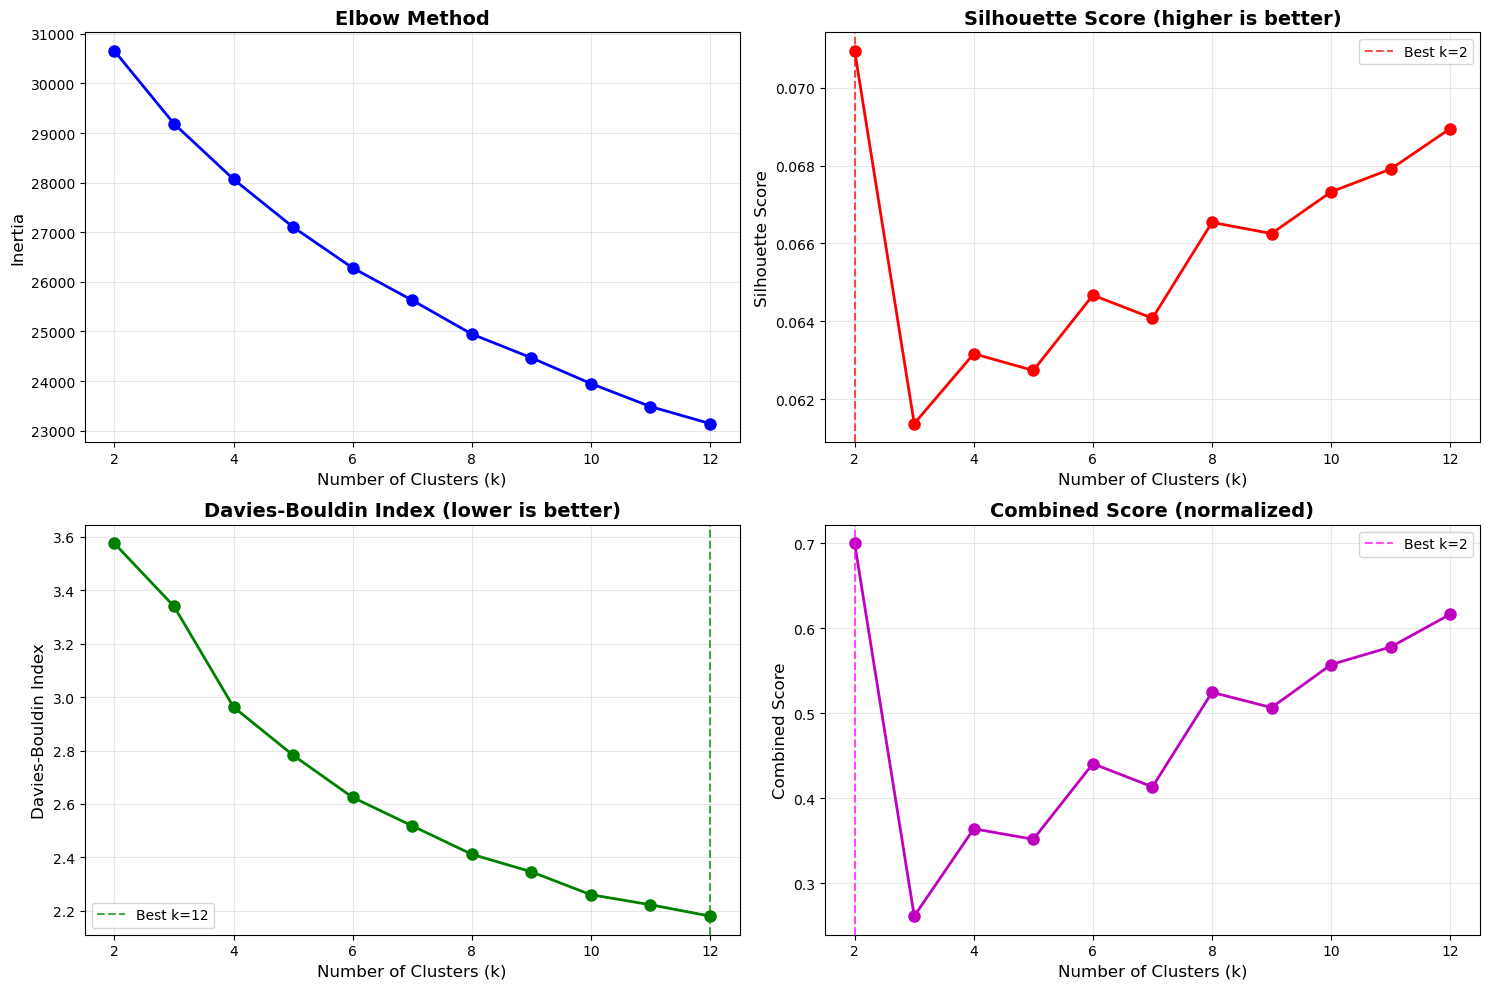


📊 Plot saved as 'cluster_optimization.png'


In [104]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import pandas as pd

# ===== PREPARE DATA FOR CLUSTERING =====

# Select features for clustering (exclude any ID columns if present)
# Assuming all your columns are now features
features_for_clustering = df.columns.tolist()

# If you have an ID column or original categorical columns, exclude them:
# features_for_clustering = [col for col in df.columns if col not in ['UserID', 'Diet', 'Gender', 'MentalHealthCondition']]

print(f"Features used for clustering: {features_for_clustering}")
print(f"Number of features: {len(features_for_clustering)}")

X = df[features_for_clustering].values

# ===== SCALE FEATURES (CRITICAL FOR K-MEANS) =====
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\nScaled data shape: {X_scaled.shape}")

# ===== FIND OPTIMAL K =====

k_range = range(2, 13)  # test k from 2 to 12

results = {
    'k': [],
    'inertia': [],
    'silhouette': [],
    'davies_bouldin': [],
    'calinski_harabasz': []
}

print("\n" + "="*60)
print("EVALUATING DIFFERENT K VALUES...")
print("="*60)

for k in k_range:
    print(f"Testing k={k}...", end=" ")
    
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    labels = kmeans.fit_predict(X_scaled)
    
    results['k'].append(k)
    results['inertia'].append(kmeans.inertia_)
    results['silhouette'].append(silhouette_score(X_scaled, labels))
    results['davies_bouldin'].append(davies_bouldin_score(X_scaled, labels))
    results['calinski_harabasz'].append(calinski_harabasz_score(X_scaled, labels))
    
    print("✓")

results_df = pd.DataFrame(results)

# ===== DISPLAY RESULTS =====
print("\n" + "="*60)
print("CLUSTER EVALUATION METRICS")
print("="*60)
print(results_df.to_string(index=False))
print("="*60)

# Find best k for each metric
best_silhouette = results_df.loc[results_df['silhouette'].idxmax(), 'k']
best_db = results_df.loc[results_df['davies_bouldin'].idxmin(), 'k']
best_ch = results_df.loc[results_df['calinski_harabasz'].idxmax(), 'k']

print(f"\nBest k by Silhouette Score (higher better): {int(best_silhouette)}")
print(f"Best k by Davies-Bouldin (lower better): {int(best_db)}")
print(f"Best k by Calinski-Harabasz (higher better): {int(best_ch)}")

# ===== COMBINED SCORE =====
from sklearn.preprocessing import MinMaxScaler

norm_scaler = MinMaxScaler()
results_df['silhouette_norm'] = norm_scaler.fit_transform(results_df[['silhouette']])
results_df['db_norm'] = 1 - norm_scaler.fit_transform(results_df[['davies_bouldin']])  # invert
results_df['ch_norm'] = norm_scaler.fit_transform(results_df[['calinski_harabasz']])

# Weighted combined score
results_df['combined_score'] = (
    results_df['silhouette_norm'] * 0.4 +
    results_df['db_norm'] * 0.3 +
    results_df['ch_norm'] * 0.3
)

best_combined = int(results_df.loc[results_df['combined_score'].idxmax(), 'k'])

print("\n" + "="*60)
print(f"🎯 RECOMMENDED k (combined score): {best_combined}")
print("="*60)

# ===== VISUALIZE =====
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Elbow plot
axes[0, 0].plot(results_df['k'], results_df['inertia'], 'bo-', linewidth=2, markersize=8)
axes[0, 0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0, 0].set_ylabel('Inertia', fontsize=12)
axes[0, 0].set_title('Elbow Method', fontsize=14, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# Silhouette
axes[0, 1].plot(results_df['k'], results_df['silhouette'], 'ro-', linewidth=2, markersize=8)
axes[0, 1].axvline(x=best_silhouette, color='red', linestyle='--', alpha=0.7, label=f'Best k={int(best_silhouette)}')
axes[0, 1].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0, 1].set_ylabel('Silhouette Score', fontsize=12)
axes[0, 1].set_title('Silhouette Score (higher is better)', fontsize=14, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Davies-Bouldin
axes[1, 0].plot(results_df['k'], results_df['davies_bouldin'], 'go-', linewidth=2, markersize=8)
axes[1, 0].axvline(x=best_db, color='green', linestyle='--', alpha=0.7, label=f'Best k={int(best_db)}')
axes[1, 0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[1, 0].set_ylabel('Davies-Bouldin Index', fontsize=12)
axes[1, 0].set_title('Davies-Bouldin Index (lower is better)', fontsize=14, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Combined score
axes[1, 1].plot(results_df['k'], results_df['combined_score'], 'mo-', linewidth=2, markersize=8)
axes[1, 1].axvline(x=best_combined, color='magenta', linestyle='--', alpha=0.7, label=f'Best k={best_combined}')
axes[1, 1].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[1, 1].set_ylabel('Combined Score', fontsize=12)
axes[1, 1].set_title('Combined Score (normalized)', fontsize=14, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cluster_optimization.png', dpi=300)
plt.show()

print(f"\n📊 Plot saved as 'cluster_optimization.png'")

In [73]:
features = df.columns.tolist()

In [74]:
X = df[features].values

In [75]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [76]:
X_scaled.shape

(3000, 11)

In [77]:
k_range = range(2,13) # the range of best optimum clusters
results = {
    'k': [],
    'inertia': [],
    'silhouette_score': [],
    'davies_bouldin': [],
    'calinski_harabasz': [],
}

In [78]:
for k in k_range:
    print(f"Testing for k={k}")
    kmeans = KMeans(n_clusters=k, random_state=42,n_init=10,max_iter=300)
    labels = kmeans.fit_predict(X_scaled)

    results['k'].append(k)
    results['inertia'].append(kmeans.inertia_)
    results['silhouette_score'].append(silhouette_score(X_scaled, labels))
    results['davies_bouldin'].append(davies_bouldin_score(X_scaled, labels))
    results['calinski_harabasz'].append(calinski_harabasz_score(X_scaled, labels))
    print('Done')

Testing for k=2
Done
Testing for k=3
Done
Testing for k=4
Done
Testing for k=5
Done
Testing for k=6
Done
Testing for k=7
Done
Testing for k=8
Done
Testing for k=9
Done
Testing for k=10
Done
Testing for k=11
Done
Testing for k=12
Done


In [79]:
results_df = pd.DataFrame(results)

In [80]:
print(results_df.loc[results_df['silhouette_score'].idxmax(),'k'])

2


In [81]:
print(results_df.loc[results_df['davies_bouldin'].idxmin(),'k'])

12


In [82]:
print(results_df.loc[results_df['calinski_harabasz'].idxmax(),'k'])

2


In [106]:
# Test k=2 and see what you get
kmeans_2 = KMeans(n_clusters=2, random_state=42)
df['cluster_2'] = kmeans_2.fit_predict(X_scaled)

print("="*60)
print("CLUSTER 2 ANALYSIS")
print("="*60)

for i in range(2):
    print(f"\nCluster {i}: {len(df[df['cluster_2']==i])} users")
    cluster_data = df[df['cluster_2'] == i]
    print(f"Avg Exercise: {cluster_data['Exercise Level'].mean():.1f}")
    print(f"Avg Happiness: {cluster_data['Happiness Score'].mean():.1f}")
    print(f"Avg Sleep: {cluster_data['Sleep Hours'].mean():.1f}")
    if 'StressLevel' in df.columns:
        print("Stress distribution:")
        print(cluster_data['StressLevel'].value_counts())

# Now try k=5
print("\n" + "="*60)
print("CLUSTER 5 ANALYSIS")
print("="*60)

kmeans_5 = KMeans(n_clusters=5, random_state=42)
df['cluster_5'] = kmeans_5.fit_predict(X_scaled)

for i in range(5):
    print(f"\nCluster {i}: {len(df[df['cluster_5']==i])} users")
    cluster_data = df[df['cluster_5'] == i]
    print(f"Avg Exercise: {cluster_data['Exercise Level'].mean():.1f}")
    print(f"Avg Happiness: {cluster_data['Happiness Score'].mean():.1f}")
    print(f"Avg Sleep: {cluster_data['Sleep Hours'].mean():.1f}")

CLUSTER 2 ANALYSIS

Cluster 0: 1447 users
Avg Exercise: 1.7
Avg Happiness: 5.6
Avg Sleep: 6.5

Cluster 1: 1553 users
Avg Exercise: 0.3
Avg Happiness: 5.2
Avg Sleep: 6.4

CLUSTER 5 ANALYSIS

Cluster 0: 633 users
Avg Exercise: 1.7
Avg Happiness: 7.7
Avg Sleep: 6.5

Cluster 1: 624 users
Avg Exercise: 0.6
Avg Happiness: 3.5
Avg Sleep: 6.1

Cluster 2: 619 users
Avg Exercise: 0.8
Avg Happiness: 5.2
Avg Sleep: 6.7

Cluster 3: 591 users
Avg Exercise: 0.3
Avg Happiness: 7.0
Avg Sleep: 6.5

Cluster 4: 533 users
Avg Exercise: 1.5
Avg Happiness: 3.4
Avg Sleep: 6.6


In [108]:
# Full analysis of k=5
kmeans_final = KMeans(n_clusters=5, random_state=42, n_init=10)
df['cluster'] = kmeans_final.fit_predict(X_scaled)

print("="*60)
print("DETAILED CLUSTER ANALYSIS (k=5)")
print("="*60)

for i in range(5):
    print(f"\n{'='*60}")
    print(f"CLUSTER {i} - {len(df[df['cluster']==i])} users ({len(df[df['cluster']==i])/len(df)*100:.1f}%)")
    print(f"{'='*60}")
    
    cluster_data = df[df['cluster'] == i]
    
    # Numerical features
    print(f"Age: {cluster_data['Age'].mean():.1f} (±{cluster_data['Age'].std():.1f})")
    print(f"Exercise Level: {cluster_data['Exercise Level'].mean():.1f}")
    print(f"Sleep Hours: {cluster_data['Sleep Hours'].mean():.1f}")
    print(f"Happiness Score: {cluster_data['Happiness Score'].mean():.1f}")
    
    if 'Work Hours per Week' in df.columns:
        print(f"Work Hours: {cluster_data['Work Hours per Week'].mean():.1f}")
    if 'Screen Time per Day (Hours)' in df.columns:
        print(f"Screen Time: {cluster_data['Screen Time per Day (Hours)'].mean():.1f}")
    if 'Social Interaction Score' in df.columns:
        print(f"Social Interaction: {cluster_data['Social Interaction Score'].mean():.1f}")
    
    # Categorical features (if you kept originals or have encoded versions)
    print("\nCategorical Distributions:")
    
    # Check what categorical columns you have
    categorical_cols = ['Gender', 'StressLevel', 'MentalHealthCondition', 'DietType']
    for col in categorical_cols:
        if col in df.columns:
            print(f"\n{col}:")
            print(cluster_data[col].value_counts().head(3))  # top 3 values



DETAILED CLUSTER ANALYSIS (k=5)

CLUSTER 0 - 600 users (20.0%)
Age: 50.3 (±10.8)
Exercise Level: 0.9
Sleep Hours: 5.8
Happiness Score: 4.4
Work Hours: 37.7
Screen Time: 5.1
Social Interaction: 4.8

Categorical Distributions:

Gender:
Gender
0    393
1    177
2     30
Name: count, dtype: int64

CLUSTER 1 - 623 users (20.8%)
Age: 32.0 (±10.5)
Exercise Level: 1.1
Sleep Hours: 7.0
Happiness Score: 5.5
Work Hours: 39.3
Screen Time: 5.2
Social Interaction: 6.7

Categorical Distributions:

Gender:
Gender
1    260
2    234
0    129
Name: count, dtype: int64

CLUSTER 2 - 574 users (19.1%)
Age: 41.2 (±13.0)
Exercise Level: 0.8
Sleep Hours: 6.2
Happiness Score: 3.3
Work Hours: 38.7
Screen Time: 5.0
Social Interaction: 6.2

Categorical Distributions:

Gender:
Gender
2    353
1    215
0      6
Name: count, dtype: int64

CLUSTER 3 - 610 users (20.3%)
Age: 45.7 (±12.3)
Exercise Level: 1.3
Sleep Hours: 6.5
Happiness Score: 7.2
Work Hours: 39.5
Screen Time: 4.9
Social Interaction: 4.1

Categorical Dist

In [109]:
df.columns.to_list()

['Age',
 'Gender',
 'Exercise Level',
 'Diet Type',
 'Sleep Hours',
 'Stress Level',
 'Mental Health Condition',
 'Work Hours per Week',
 'Screen Time per Day (Hours)',
 'Social Interaction Score',
 'Happiness Score',
 'cluster_2',
 'cluster_5',
 'cluster']

In [110]:
# Full analysis with categorical features
for i in range(5):
    cluster_data = df[df['cluster'] == i]
    print(f"\n{'='*70}")
    print(f"CLUSTER {i} - {len(cluster_data)} users ({len(cluster_data)/len(df)*100:.1f}%)")
    print(f"{'='*70}")
    
    # Numerical averages
    print(f"Age: {cluster_data['Age'].mean():.1f}")
    print(f"Exercise Level: {cluster_data['Exercise Level'].mean():.1f}")
    print(f"Sleep Hours: {cluster_data['Sleep Hours'].mean():.1f}")
    print(f"Happiness Score: {cluster_data['Happiness Score'].mean():.1f}")
    print(f"Work Hours: {cluster_data['Work Hours per Week'].mean():.1f}")
    print(f"Screen Time: {cluster_data['Screen Time per Day (Hours)'].mean():.1f}")
    print(f"Social Interaction: {cluster_data['Social Interaction Score'].mean():.1f}")
    
    # KEY FEATURES FOR NAMING
    print(f"\n--- STRESS LEVEL ---")
    print(cluster_data['Stress Level'].value_counts())
    
    print(f"\n--- MENTAL HEALTH ---")
    print(cluster_data['Mental Health Condition'].value_counts())
    
    print(f"\n--- DIET TYPE ---")
    print(cluster_data['Diet Type'].value_counts())
    
    print(f"\n--- GENDER ---")
    print(cluster_data['Gender'].value_counts())


CLUSTER 0 - 600 users (20.0%)
Age: 50.3
Exercise Level: 0.9
Sleep Hours: 5.8
Happiness Score: 4.4
Work Hours: 37.7
Screen Time: 5.1
Social Interaction: 4.8

--- STRESS LEVEL ---
Stress Level
2    368
1    203
0     29
Name: count, dtype: int64

--- MENTAL HEALTH ---
Mental Health Condition
3    132
2    129
1    124
4    118
0     97
Name: count, dtype: int64

--- DIET TYPE ---
Diet Type
0    148
2    133
1    124
3    115
4     80
Name: count, dtype: int64

--- GENDER ---
Gender
0    393
1    177
2     30
Name: count, dtype: int64

CLUSTER 1 - 623 users (20.8%)
Age: 32.0
Exercise Level: 1.1
Sleep Hours: 7.0
Happiness Score: 5.5
Work Hours: 39.3
Screen Time: 5.2
Social Interaction: 6.7

--- STRESS LEVEL ---
Stress Level
2    485
1    138
Name: count, dtype: int64

--- MENTAL HEALTH ---
Mental Health Condition
3    159
4    155
2    120
1    105
0     84
Name: count, dtype: int64

--- DIET TYPE ---
Diet Type
3    159
4    150
2    120
1    100
0     94
Name: count, dtype: int64

--- GE

In [111]:
# Map cluster numbers to meaningful names
cluster_names = {
    0: 'Older_HighStress_Exhausted',
    1: 'Young_HighStress_ActiveSocial',
    2: 'MidLife_LowStress_Depressed',
    3: 'MidLife_Thriving_WellnessSeeker',
    4: 'WorkingProfessional_Sedentary_Stable'
}

# Add named labels to dataframe
df['ProgramLabel'] = df['cluster'].map(cluster_names)

# Check distribution
print("\nProgram Label Distribution:")
print(df['ProgramLabel'].value_counts())

# Save the dataframe with labels
df.to_csv('wellness_data_clustered.csv', index=False)
print("\n✓ Saved clustered data to 'wellness_data_clustered.csv'")


Program Label Distribution:
ProgramLabel
Young_HighStress_ActiveSocial           623
MidLife_Thriving_WellnessSeeker         610
Older_HighStress_Exhausted              600
WorkingProfessional_Sedentary_Stable    593
MidLife_LowStress_Depressed             574
Name: count, dtype: int64

✓ Saved clustered data to 'wellness_data_clustered.csv'
